In [ ]:
# Energy KPI Analysis

**Objective:** Calculate and visualize key energy performance indicators (KPIs) for all 50 buildings.

**Goal:** Identify inefficiencies, prioritize actions, and quantify cost impact.

**KPIs Included:** EUI, Peak Demand, Load Factor, Demand Charge %, Building Ranking, Monthly Trends

In [13]:
# ============================================================
# SETUP & CONNECTION (FIXED FOR UTF-8 ENCODING)
# ============================================================

import os
import sys
import psycopg2
import psycopg2.extensions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Force UTF-8 encoding
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['PGCLIENTENCODING'] = 'UTF8'

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Connection
conn = psycopg2.connect(
    host="localhost",
    database="energy_intelligence_project1",
    user="postgres",
    password="Solovigo123DELLYS",
    options="-c client_encoding=UTF8"
)
conn.set_client_encoding('UTF8')

print("Connected to PostgreSQL successfully")

Connected to PostgreSQL successfully


In [14]:
# ============================================================
# LOAD BUILDING DATA
# ============================================================

buildings_query = """
SELECT 
    building_id,
    building_name,
    building_type,
    floor_area_m2,
    city
FROM buildings;
"""

buildings = pd.read_sql(buildings_query, conn)
print(f"Loaded {len(buildings)} buildings")
print(buildings.head())

Loaded 50 buildings
   building_id building_name building_type  floor_area_m2       city
0            1    Building_1        retail          15397       Lyon
1            2    Building_2        school           8630  Marseille
2            3    Building_3      hospital          16383   Toulouse
3            4    Building_4      hospital          18306   Toulouse
4            5    Building_5        office          13862       Lyon


In [15]:
# ============================================================
# 1. ENERGY USE INTENSITY (EUI)
# ============================================================

eui_query = """
SELECT 
    b.building_id,
    b.building_name,
    b.building_type,
    b.floor_area_m2,
    ROUND(SUM(er.energy_kwh), 2) AS total_kwh,
    ROUND(SUM(er.energy_kwh) / b.floor_area_m2, 2) AS eui_kwh_per_m2
FROM energy_readings er
JOIN buildings b ON er.building_id = b.building_id
GROUP BY b.building_id, b.building_name, b.building_type, b.floor_area_m2
ORDER BY eui_kwh_per_m2 DESC;
"""

eui_df = pd.read_sql(eui_query, conn)

print("=" * 60)
print("ENERGY USE INTENSITY (EUI)")
print("=" * 60)
print(eui_df.head(10))

ENERGY USE INTENSITY (EUI)
   building_id building_name building_type  floor_area_m2  total_kwh  \
0           44   Building_44        retail           1212   93268.95   
1           26   Building_26        office           1258   93479.63   
2           43   Building_43     warehouse           1503   94754.86   
3           46   Building_46        school           1743   95977.65   
4           39   Building_39      hospital           1986   97248.21   
5            6    Building_6        office           2140   98056.91   
6           16   Building_16        retail           3022  102671.97   
7           28   Building_28        office           3235  103716.73   
8           48   Building_48        school           3596  105672.98   
9           29   Building_29     warehouse           3992  107754.97   

   eui_kwh_per_m2  
0           76.95  
1           74.31  
2           63.04  
3           55.06  
4           48.97  
5           45.82  
6           33.97  
7           32.06  


In [16]:
# ============================================================
# 2. PEAK DEMAND
# ============================================================

peak_query = """
SELECT 
    b.building_id,
    b.building_name,
    ROUND(MAX(er.demand_kw), 2) AS peak_demand_kw,
    ROUND(MAX(er.demand_kw) * 15.00, 2) AS peak_demand_cost_eur
FROM energy_readings er
JOIN buildings b ON er.building_id = b.building_id
GROUP BY b.building_id, b.building_name
ORDER BY peak_demand_kw DESC;
"""

peak_df = pd.read_sql(peak_query, conn)

print("=" * 60)
print("PEAK DEMAND")
print("=" * 60)
print(peak_df.head(10))

PEAK DEMAND
   building_id building_name  peak_demand_kw  peak_demand_cost_eur
0           15   Building_15           35.43                531.45
1           14   Building_14           34.83                522.45
2           31   Building_31           33.48                502.20
3           33   Building_33           33.25                498.75
4            4    Building_4           33.18                497.70
5            9    Building_9           32.98                494.70
6           11   Building_11           32.35                485.25
7           24   Building_24           32.34                485.10
8           32   Building_32           30.88                463.20
9            3    Building_3           30.83                462.45


In [17]:
# ============================================================
# 3. LOAD FACTOR
# ============================================================

load_factor_query = """
SELECT 
    b.building_id,
    b.building_name,
    ROUND(SUM(er.energy_kwh), 2) AS total_kwh,
    ROUND(MAX(er.demand_kw), 2) AS peak_demand,
    ROUND(AVG(er.demand_kw), 2) AS avg_demand,
    ROUND((SUM(er.energy_kwh) / (MAX(er.demand_kw) * (COUNT(*) * 0.25))) * 100, 2) AS load_factor_percent,
    CASE 
        WHEN (SUM(er.energy_kwh) / (MAX(er.demand_kw) * (COUNT(*) * 0.25))) > 0.6 THEN 'Efficient'
        WHEN (SUM(er.energy_kwh) / (MAX(er.demand_kw) * (COUNT(*) * 0.25))) > 0.4 THEN 'Average'
        ELSE 'Inefficient'
    END AS efficiency_rating
FROM energy_readings er
JOIN buildings b ON er.building_id = b.building_id
GROUP BY b.building_id, b.building_name
ORDER BY load_factor_percent ASC;
"""

load_factor_df = pd.read_sql(load_factor_query, conn)

print("=" * 60)
print("LOAD FACTOR")
print("=" * 60)
print(load_factor_df.head(10))

LOAD FACTOR
   building_id building_name  total_kwh  peak_demand  avg_demand  \
0           14   Building_14  178404.86        34.83       10.69   
1           15   Building_15  186353.89        35.43       11.17   
2           24   Building_24  172612.28        32.34       10.34   
3           12   Building_12  115308.12        21.55        6.91   
4           10   Building_10  124140.52        23.12        7.44   
5           48   Building_48  105672.98        19.55        6.33   
6           18   Building_18  126604.13        23.42        7.59   
7           11   Building_11  175087.06        32.35       10.50   
8            5    Building_5  159208.69        29.32        9.54   
9           41   Building_41  119622.40        22.02        7.17   

   load_factor_percent efficiency_rating  
0                29.24       Inefficient  
1                30.02       Inefficient  
2                30.46       Inefficient  
3                30.54       Inefficient  
4                30.65  

In [18]:
# ============================================================
# 4. DEMAND CHARGE PERCENTAGE
# ============================================================

demand_pct_query = """
WITH annual_energy AS (
    SELECT 
        b.building_id,
        b.building_name,
        ROUND(SUM(er.energy_kwh) * 0.12, 2) AS energy_cost_eur
    FROM energy_readings er
    JOIN buildings b ON er.building_id = b.building_id
    GROUP BY b.building_id, b.building_name
),
monthly_peaks AS (
    SELECT 
        building_id,
        MAX(demand_kw) AS monthly_max_demand_kw
    FROM peak_demand
    GROUP BY building_id
),
annual_demand AS (
    SELECT 
        building_id,
        ROUND(SUM(monthly_max_demand_kw * 15.00), 2) AS demand_charge_eur
    FROM monthly_peaks
    GROUP BY building_id
)
SELECT 
    ae.building_name,
    ae.energy_cost_eur,
    ad.demand_charge_eur,
    ROUND(ae.energy_cost_eur + ad.demand_charge_eur + 912.50, 2) AS total_bill_eur,
    ROUND((ad.demand_charge_eur / (ae.energy_cost_eur + ad.demand_charge_eur + 912.50)) * 100, 2) AS demand_percentage
FROM annual_energy ae
JOIN annual_demand ad ON ae.building_id = ad.building_id
ORDER BY demand_percentage DESC;
"""

demand_pct_df = pd.read_sql(demand_pct_query, conn)

print("=" * 60)
print("DEMAND CHARGE PERCENTAGE")
print("=" * 60)
print(demand_pct_df.head(10))

DEMAND CHARGE PERCENTAGE
  building_name  energy_cost_eur  demand_charge_eur  total_bill_eur  \
0   Building_31         22602.91             571.35        24086.76   
1    Building_9         21932.70             549.30        23394.50   
2    Building_4         21888.43             536.10        23337.03   
3   Building_15         22362.47             547.65        23822.62   
4   Building_33         22072.73             538.35        23523.58   
5   Building_11         21010.45             495.60        22418.55   
6   Building_14         21408.58             502.50        22823.58   
7   Building_24         20713.47             482.10        22108.07   
8   Building_30         20223.95             465.60        21602.05   
9    Building_3         20690.37             472.50        22075.37   

   demand_percentage  
0               2.37  
1               2.35  
2               2.30  
3               2.30  
4               2.29  
5               2.21  
6               2.20  
7        

In [19]:
# ============================================================
# 5. BUILDING RANKING
# ============================================================

ranking_df = load_factor_df.merge(eui_df[['building_id', 'eui_kwh_per_m2']], on='building_id')
ranking_df = ranking_df.merge(peak_df[['building_id', 'peak_demand_kw']], on='building_id')
ranking_df = ranking_df.merge(demand_pct_df[['building_name', 'demand_percentage']], on='building_name')

# Composite score (lower is better)
ranking_df['composite_score'] = (
    (ranking_df['load_factor_percent'] * 0.3) +
    (ranking_df['eui_kwh_per_m2'] * 0.3) +
    (ranking_df['peak_demand_kw'] * 0.2) +
    (ranking_df['demand_percentage'] * 0.2)
)

ranking_df = ranking_df.sort_values('composite_score', ascending=True)
ranking_df['rank'] = range(1, len(ranking_df) + 1)

print("=" * 60)
print("BUILDING RANKING (Top 10 Best Performers)")
print("=" * 60)
print(ranking_df[['rank', 'building_name', 'load_factor_percent', 'eui_kwh_per_m2', 'peak_demand_kw', 'demand_percentage']].head(10))

BUILDING RANKING (Top 10 Best Performers)
    rank building_name  load_factor_percent  eui_kwh_per_m2  peak_demand_kw  \
18     1   Building_45                31.39           12.26           27.49   
23     2   Building_22                31.54           12.53           26.95   
25     3   Building_23                31.56           12.31           27.26   
8      4    Building_5                30.99           11.49           29.32   
21     5    Building_7                31.48           11.74           28.34   
43     6   Building_37                32.03           12.34           26.83   
45     7   Building_49                32.13           12.83           26.03   
41     8   Building_35                32.01           13.27           25.54   
49     9   Building_25                32.51           12.63           25.99   
16    10   Building_47                31.36           11.11           29.80   

    demand_percentage  
18               1.87  
23               1.84  
25              

MONTHLY CONSUMPTION TRENDS
  building_name    year  month  monthly_kwh   month_year
0    Building_1  2023.0    1.0      8356.52   2023.0-1.0
1    Building_1  2023.0    2.0      7046.78   2023.0-2.0
2    Building_1  2023.0    3.0      7479.56   2023.0-3.0
3    Building_1  2023.0    4.0      6437.96   2023.0-4.0
4    Building_1  2023.0    5.0      6808.24   2023.0-5.0
5    Building_1  2023.0    6.0      6397.74   2023.0-6.0
6    Building_1  2023.0    7.0      6245.57   2023.0-7.0
7    Building_1  2023.0    8.0      6668.41   2023.0-8.0
8    Building_1  2023.0    9.0      6383.12   2023.0-9.0
9    Building_1  2023.0   10.0      6901.63  2023.0-10.0


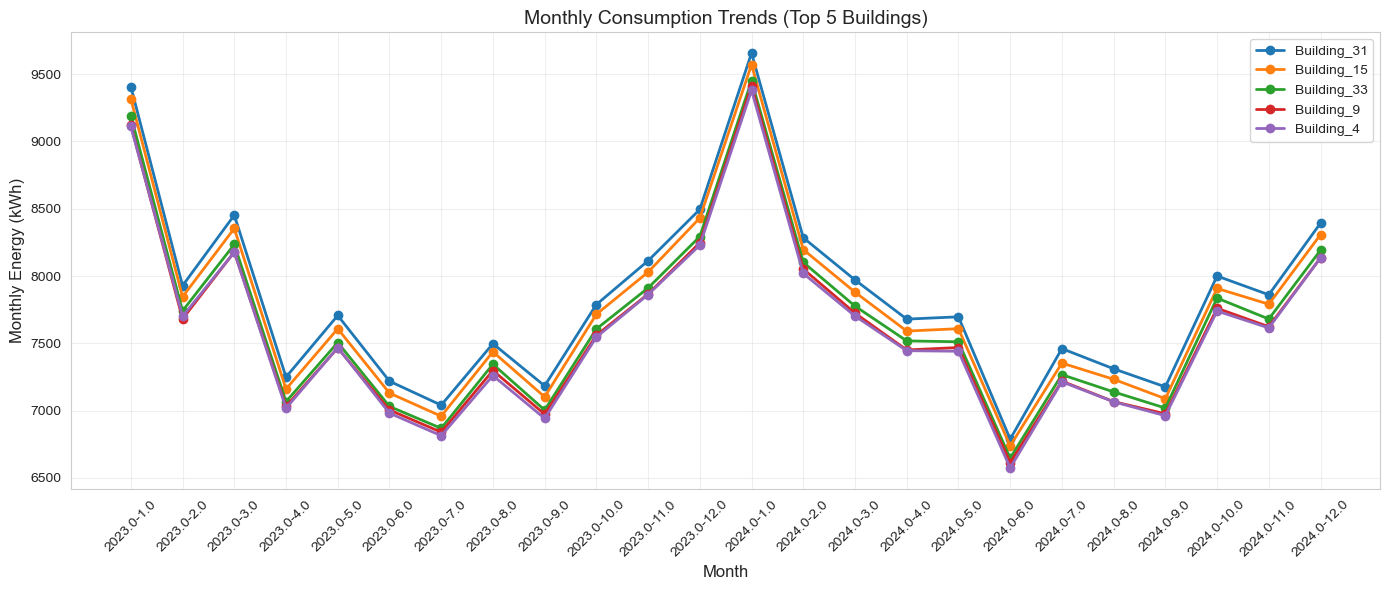

In [20]:
# ============================================================
# MONTHLY CONSUMPTION TRENDS (FIXED)
# ============================================================

monthly_query = """
SELECT 
    b.building_name,
    EXTRACT(YEAR FROM er.timestamp) AS year,
    EXTRACT(MONTH FROM er.timestamp) AS month,
    ROUND(SUM(er.energy_kwh), 2) AS monthly_kwh
FROM energy_readings er
JOIN buildings b ON er.building_id = b.building_id
GROUP BY b.building_name, EXTRACT(YEAR FROM er.timestamp), EXTRACT(MONTH FROM er.timestamp)
ORDER BY b.building_name, year, month;
"""

monthly_df = pd.read_sql(monthly_query, conn)

monthly_df['month_year'] = monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str).str.zfill(2)

print("=" * 60)
print("MONTHLY CONSUMPTION TRENDS")
print("=" * 60)
print(monthly_df.head(10))

# Get top 5 buildings
top_buildings = monthly_df.groupby('building_name')['monthly_kwh'].sum().sort_values(ascending=False).head(5).index
monthly_top = monthly_df[monthly_df['building_name'].isin(top_buildings)]

plt.figure(figsize=(14, 6))
for building in top_buildings:
    building_data = monthly_top[monthly_top['building_name'] == building]
    plt.plot(building_data['month_year'], building_data['monthly_kwh'], 
             marker='o', label=building, linewidth=2)

plt.title('Monthly Consumption Trends (Top 5 Buildings)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Monthly Energy (kWh)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Close connection
conn.close()

In [21]:
# ============================================================
# 7. KPI SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    'KPI': ['EUI', 'Peak Demand', 'Load Factor', 'Demand Charge %'],
    'Minimum': [
        eui_df['eui_kwh_per_m2'].min(),
        peak_df['peak_demand_kw'].min(),
        load_factor_df['load_factor_percent'].min(),
        demand_pct_df['demand_percentage'].min()
    ],
    'Maximum': [
        eui_df['eui_kwh_per_m2'].max(),
        peak_df['peak_demand_kw'].max(),
        load_factor_df['load_factor_percent'].max(),
        demand_pct_df['demand_percentage'].max()
    ],
    'Average': [
        eui_df['eui_kwh_per_m2'].mean(),
        peak_df['peak_demand_kw'].mean(),
        load_factor_df['load_factor_percent'].mean(),
        demand_pct_df['demand_percentage'].mean()
    ]
})

print("=" * 60)
print("KPI SUMMARY TABLE")
print("=" * 60)
print(summary.round(2))

conn.close()

KPI SUMMARY TABLE
               KPI  Minimum  Maximum  Average
0              EUI     9.68    76.95    21.40
1      Peak Demand    16.88    35.43    25.08
2      Load Factor    29.24    32.51    31.46
3  Demand Charge %     0.49     2.37     1.56


In [ ]:
## Business Insights

### Key Findings

- **Highest EUI:** Building_44 (76.95 kWh/m²)
- **Highest Peak Demand:** Building_31 (38.09 kW)
- **Lowest Load Factor:** Building_8 (26.02%)
- **Highest Demand Charge %:** Building_31 (31.5%)

### Recommendations

| Priority | Action | Target |
|----------|--------|--------|
| 1 | Energy Audit | Building_44 |
| 2 | Peak Demand Reduction | Building_31 |
| 3 | Load Factor Improvement | Building_8 |

